# Solar Filament Segmentation — inference and Kaggle submission notebook

**Francesco Peluso** (`IE22700088`, f.peluso29@studenti.unisa.it)
Machine Learning A.Y. 2025/26 — MSc Computer Engineering, DIEM, University of Salerno
[filament-segmentation-2026](https://www.kaggle.com/competitions/filament-segmentation-2026)

Takes a trained experiment and writes `submission.csv`. It trains nothing and tunes
nothing: the threshold and the post-processing are read from
`experiments/<ID>/metrics/submission_recipe.json`, where `01_training.ipynb` froze them
after selecting them on validation. Choosing them here, while looking at the test
images, would be tuning on the test set.

In [10]:
import subprocess
import sys
from pathlib import Path

ON_COLAB = "google.colab" in sys.modules
if ON_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pycocotools"], check=False)


def locate_project() -> Path:
    """Find the project root from wherever this notebook was opened."""
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "dataset").is_dir() or (candidate / "experiments").is_dir():
            return candidate
    for candidate in (Path("/content/MachineLearning-Project"),
                      Path("/kaggle/working/MachineLearning-Project")):
        if candidate.is_dir():
            return candidate
    return Path.cwd()


PROJECT_ROOT = locate_project()

# The competition zip's own layout nests everything one level deeper
# (dataset/MAGFiLO_1.0_Kaggle_2026/train/...) than a plain "dataset/train/..." tree
# does. Both are accepted below, whichever a local copy or a kagglehub download hands
# back, so no extra path-fixing cell is ever needed.
def _has_dataset(root: Path) -> bool:
    return (root / "train").is_dir() or (root / "MAGFiLO_1.0_Kaggle_2026").is_dir()


DATASET_DIR = PROJECT_ROOT / "dataset"

if ON_COLAB and not _has_dataset(DATASET_DIR):
    # Nothing local yet (no Drive mount, no manual unzip): pull the competition data
    # straight from Kaggle. This needs Kaggle credentials available in the session
    # (Colab Secrets KAGGLE_USERNAME/KAGGLE_KEY, a kaggle.json, or kagglehub's own
    # interactive login) and the competition rules accepted on kaggle.com - if either
    # is missing, kagglehub raises its own clear error here rather than failing later
    # with a bare FileNotFoundError deep inside data loading.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=False)
    import kagglehub
    DATASET_DIR = Path(kagglehub.competition_download("filament-segmentation-2026"))
    print(f"downloaded competition data to {DATASET_DIR}")

if not (DATASET_DIR / "train").is_dir() and (DATASET_DIR / "MAGFiLO_1.0_Kaggle_2026").is_dir():
    DATASET_DIR = DATASET_DIR / "MAGFiLO_1.0_Kaggle_2026"
TRAIN_IMAGES = DATASET_DIR / "train" / "train_images"
ANNOTATIONS = DATASET_DIR / "train" / "MAGFiLO_1.0_Annotations_kaggle2026_train.json"
TEST_IMAGES = DATASET_DIR / "test" / "test_images"

print(f"project : {PROJECT_ROOT}")
print(f"dataset : {DATASET_DIR}  (exists: {DATASET_DIR.is_dir()})")
if not ANNOTATIONS.is_file():
    listing = sorted(p.name for p in DATASET_DIR.iterdir()) if DATASET_DIR.is_dir() else []
    print(f"WARNING: annotations not found at {ANNOTATIONS}")
    print(f"  contents of {DATASET_DIR}: {listing}")

project : /Users/fp/GitHub Repos/MachineLearning-Project
dataset : /Users/fp/GitHub Repos/MachineLearning-Project/dataset  (exists: True)


In [11]:
import json
import os
import platform
import random
import sys
import time
from contextlib import nullcontext

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image, ImageDraw
from scipy import ndimage
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

SEED = 22


def seed_everything(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


class Runtime:
    """Everything that depends on the accelerator we happen to be running on
    (CUDA on Colab, MPS on a MacBook, or plain CPU), probed once at start-up."""

    def __init__(self, num_workers=None):
        if torch.cuda.is_available():
            self.device = torch.device("cuda")
            torch.backends.cudnn.benchmark = True
            torch.backends.cuda.matmul.allow_tf32 = True
            torch.backends.cudnn.allow_tf32 = True
        elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
            self.device = torch.device("mps")
            torch.set_float32_matmul_precision("high")
        else:
            self.device = torch.device("cpu")

        self.amp_dtype, self.needs_scaler = self._probe_autocast()
        self.channels_last = self.device.type == "cuda"
        self.pin_memory = self.device.type == "cuda"
        # With the uint8 cache in place one process already feeds ~160 samples/s,
        # more than any of these GPUs can consume, so workers only pay off on
        # CUDA hosts where fork is cheap.
        cpus = os.cpu_count() or 2
        self.num_workers = num_workers if num_workers is not None else (
            min(4, max(0, cpus - 2)) if self.device.type == "cuda" else 0)
        self._peak = 0

    def _probe_autocast(self):
        if self.device.type == "cpu":
            return None, False
        for dtype in (torch.bfloat16, torch.float16):
            try:
                with torch.autocast(device_type=self.device.type, dtype=dtype):
                    probe = torch.ones(8, 8, device=self.device)
                    if float((probe @ probe).float().sum()) != 512.0:
                        continue
            except Exception:
                continue
            return dtype, dtype is torch.float16 and self.device.type == "cuda"
        return None, False

    def autocast(self):
        return (nullcontext() if self.amp_dtype is None
                else torch.autocast(device_type=self.device.type, dtype=self.amp_dtype))

    def grad_scaler(self):
        return torch.amp.GradScaler(self.device.type, enabled=self.needs_scaler)

    def prepare(self, obj):
        obj = obj.to(self.device, non_blocking=self.pin_memory)
        if self.channels_last and (not torch.is_tensor(obj) or obj.dim() == 4):
            obj = obj.to(memory_format=torch.channels_last)
        return obj

    def loader_kwargs(self, batch_size):
        kwargs = {"batch_size": batch_size, "num_workers": self.num_workers,
                  "pin_memory": self.pin_memory}
        if self.num_workers:
            kwargs.update(persistent_workers=True, prefetch_factor=4)
        return kwargs

    # Peak memory: the assignment gives a bonus below 5 GB training / 4 GB test.
    # CUDA tracks the peak itself; MPS has no peak counter and its pool figure
    # over-reports, so live allocation is sampled at the point a step peaks.
    def reset_peak_memory(self):
        self._peak = 0
        if self.device.type == "cuda":
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.empty_cache()
        elif self.device.type == "mps":
            torch.mps.empty_cache()

    def note_memory(self):
        if self.device.type == "mps":
            self._peak = max(self._peak, torch.mps.current_allocated_memory())

    def peak_memory_gb(self):
        """Peak of live tensors: comparable across backends, the figure to quote."""
        if self.device.type == "cuda":
            return torch.cuda.max_memory_allocated() / 1024 ** 3
        if self.device.type == "mps":
            return (self._peak or torch.mps.driver_allocated_memory()) / 1024 ** 3
        return float("nan")

    def reserved_memory_gb(self):
        """What the allocator holds, cache included: a conservative upper bound.

        In inference the live figure under-reports, because nothing keeps the
        activations alive long enough to be sampled between steps; this one does
        not have that problem.
        """
        if self.device.type == "cuda":
            return torch.cuda.max_memory_reserved() / 1024 ** 3
        if self.device.type == "mps":
            return torch.mps.driver_allocated_memory() / 1024 ** 3
        return float("nan")

    def summary(self):
        name = (torch.cuda.get_device_name(0) if self.device.type == "cuda"
                else f"Apple Silicon GPU ({platform.machine()})" if self.device.type == "mps"
                else platform.processor() or "CPU")
        dtype = str(self.amp_dtype).replace("torch.", "") if self.amp_dtype else "disabled"
        return (f"device       : {self.device} ({name})\n"
                f"autocast     : {dtype}{' + GradScaler' if self.needs_scaler else ''}\n"
                f"channels_last: {self.channels_last} | dataloader workers: {self.num_workers}\n"
                f"torch {torch.__version__} | python {sys.version.split()[0]}")

    def info(self):
        return {"device": str(self.device), "autocast": str(self.amp_dtype),
                "channels_last": self.channels_last, "num_workers": self.num_workers,
                "torch": torch.__version__, "python": sys.version.split()[0],
                "platform": platform.platform()}


seed_everything()
runtime = Runtime()
print(runtime.summary())

device       : mps (Apple Silicon GPU (arm64))
autocast     : bfloat16
channels_last: False | dataloader workers: 0
torch 2.12.0 | python 3.14.3


## 1. Model and frozen recipe

The model definition below is copied verbatim from the training notebook, so this file
runs on its own (on Colab, Kaggle or a laptop) without importing anything from the
project.

In [12]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True))

    def forward(self, x):
        return self.block(x)


class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)
        self.conv = DoubleConv(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        return self.conv(torch.cat((skip, x), dim=1))


class UNet(nn.Module):
    """Baseline: four levels, 16 filters at the first, 1.9 M parameters."""

    def __init__(self, in_channels=1, out_channels=1, base_channels=16):
        super().__init__()
        c = base_channels
        self.pool = nn.MaxPool2d(2, 2)
        self.encoder_1, self.encoder_2 = DoubleConv(in_channels, c), DoubleConv(c, c * 2)
        self.encoder_3, self.encoder_4 = DoubleConv(c * 2, c * 4), DoubleConv(c * 4, c * 8)
        self.bottleneck = DoubleConv(c * 8, c * 16)
        self.decoder_4 = DecoderBlock(c * 16, c * 8, c * 8)
        self.decoder_3 = DecoderBlock(c * 8, c * 4, c * 4)
        self.decoder_2 = DecoderBlock(c * 4, c * 2, c * 2)
        self.decoder_1 = DecoderBlock(c * 2, c, c)
        self.output = nn.Conv2d(c, out_channels, 1)

    def forward(self, x):
        s1 = self.encoder_1(x)
        s2 = self.encoder_2(self.pool(s1))
        s3 = self.encoder_3(self.pool(s2))
        s4 = self.encoder_4(self.pool(s3))
        x = self.bottleneck(self.pool(s4))
        x = self.decoder_4(x, s4)
        x = self.decoder_3(x, s3)
        x = self.decoder_2(x, s2)
        x = self.decoder_1(x, s1)
        return self.output(x)


def fold_stem_to_grayscale(conv, bn, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Turn the RGB stem into an exactly equivalent single-channel one.

    Repeating a grayscale channel three times and normalising with the RGB
    mean/std is algebraically a 1-channel convolution plus a constant:

        sum_c W_c * (g - m_c)/s_c  =  (sum_c W_c/s_c) * g  -  k

    and the constant k is absorbed into the running mean of the batch norm
    that follows. Same output, a third of the input bandwidth.
    """
    weight = conv.weight.data
    std_t = torch.tensor(std, dtype=weight.dtype).view(1, 3, 1, 1)
    mean_t = torch.tensor(mean, dtype=weight.dtype).view(1, 3, 1, 1)
    gray = nn.Conv2d(1, conv.out_channels, conv.kernel_size, conv.stride, conv.padding, bias=False)
    gray.weight.data.copy_((weight / std_t).sum(dim=1, keepdim=True))
    bn.running_mean.data.add_((weight * mean_t / std_t).sum(dim=(1, 2, 3)))
    return gray


class ResNet18UNet(nn.Module):
    """ResNet18 encoder, U-Net decoder, one logit per pixel.

    With fewer than 500 training observations, learning edges and textures from
    scratch wastes the data budget, so the encoder starts from ImageNet.
    """

    def __init__(self, out_channels=1, pretrained=True, in_channels=1,
                 gradient_checkpointing=False):
        super().__init__()
        from torchvision.models import ResNet18_Weights, resnet18
        self.in_channels = in_channels
        # Recompute activations in the backward pass instead of storing them: about
        # 40% less memory for about 25% more time. Only needed at 1536 and above, where
        # storing them would push training past the 5 GB the assignment rewards.
        self.gradient_checkpointing = gradient_checkpointing
        encoder = resnet18(weights=ResNet18_Weights.DEFAULT if pretrained else None)
        conv1, bn1 = encoder.conv1, encoder.bn1
        if in_channels == 1:
            conv1 = (fold_stem_to_grayscale(conv1, bn1) if pretrained
                     else nn.Conv2d(1, 64, 7, stride=2, padding=3, bias=False))
        self.stem = nn.Sequential(conv1, bn1, encoder.relu)
        self.maxpool = encoder.maxpool
        self.encoder_1, self.encoder_2 = encoder.layer1, encoder.layer2
        self.encoder_3, self.encoder_4 = encoder.layer3, encoder.layer4
        self.decoder_4 = DecoderBlock(512, 256, 256)
        self.decoder_3 = DecoderBlock(256, 128, 128)
        self.decoder_2 = DecoderBlock(128, 64, 64)
        self.decoder_1 = DecoderBlock(64, 64, 64)
        self.final_up = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.final_conv = DoubleConv(32, 32)
        self.output = nn.Conv2d(32, out_channels, 1)

    def _run(self, module, *args):
        if self.gradient_checkpointing and self.training and torch.is_grad_enabled():
            from torch.utils.checkpoint import checkpoint
            return checkpoint(module, *args, use_reentrant=False)
        return module(*args)

    def forward(self, x):
        if self.in_channels == 3 and x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)
        stem = self._run(self.stem, x)
        s1 = self._run(self.encoder_1, self.maxpool(stem))
        s2 = self._run(self.encoder_2, s1)
        s3 = self._run(self.encoder_3, s2)
        x = self._run(self.encoder_4, s3)
        x = self._run(self.decoder_4, x, s3)
        x = self._run(self.decoder_3, x, s2)
        x = self._run(self.decoder_2, x, s1)
        x = self._run(self.decoder_1, x, stem)
        return self.output(self.final_conv(self._run(self.final_up, x)))


def build_model(name, pretrained=True, in_channels=1, gradient_checkpointing=False):
    if name == "unet":
        return UNet(in_channels=in_channels)
    if name == "resnet18":
        return ResNet18UNet(pretrained=pretrained, in_channels=in_channels,
                            gradient_checkpointing=gradient_checkpointing)
    raise ValueError(f"unknown model {name!r}")


def load_checkpoint(model, path, device="cpu"):
    """Load a checkpoint, folding a 3-channel stem into a 1-channel one if needed."""
    payload = torch.load(Path(path), map_location=device, weights_only=False)
    state = dict(payload["model_state_dict"])
    stem, target = state.get("stem.0.weight"), model.state_dict().get("stem.0.weight")
    if stem is not None and target is not None and stem.shape != target.shape:
        # keep the folding constants on the checkpoint's device, not the default one
        std = torch.tensor(IMAGENET_STD, dtype=stem.dtype, device=stem.device).view(1, 3, 1, 1)
        mean = torch.tensor(IMAGENET_MEAN, dtype=stem.dtype, device=stem.device).view(1, 3, 1, 1)
        state["stem.0.weight"] = (stem / std).sum(dim=1, keepdim=True)
        state["stem.1.running_mean"] = (state["stem.1.running_mean"]
                                        + (stem * mean / std).sum(dim=(1, 2, 3)))
    model.load_state_dict(state)
    return {k: v for k, v in payload.items() if k != "model_state_dict"}


DIMS = (1, 2, 3)


def soft_dice(logits, targets, eps=1e-6):
    p = torch.sigmoid(logits)
    overlap = (p * targets).sum(dim=DIMS)
    return ((2 * overlap + eps) / (p.sum(dim=DIMS) + targets.sum(dim=DIMS) + eps)).mean()


def hard_dice(logits, targets, threshold=0.5, eps=1e-6):
    p = (torch.sigmoid(logits) >= threshold).to(targets.dtype)
    overlap = (p * targets).sum(dim=DIMS)
    return ((2 * overlap + eps) / (p.sum(dim=DIMS) + targets.sum(dim=DIMS) + eps)).mean()


def tversky(logits, targets, alpha=0.3, beta=0.7, eps=1e-6):
    """Dice with asymmetric weights: beta > alpha punishes missed filaments harder."""
    p = torch.sigmoid(logits)
    tp = (p * targets).sum(dim=DIMS)
    fp = (p * (1 - targets)).sum(dim=DIMS)
    fn = ((1 - p) * targets).sum(dim=DIMS)
    return ((tp + eps) / (tp + alpha * fp + beta * fn + eps)).mean()


def _soft_open(x):
    return F.max_pool2d(-F.max_pool2d(-x, 3, 1, 1), 3, 1, 1)


def soft_cldice(logits, targets, iterations=10, eps=1e-6):
    """Dice between centrelines: a broken filament costs more than a thin one."""
    def skeleton(x):
        s = F.relu(x - _soft_open(x))
        for _ in range(iterations):
            x = -F.max_pool2d(-x, 3, 1, 1)
            s = torch.clamp(s + F.relu(x - _soft_open(x)), 0.0, 1.0)
        return s
    p = torch.sigmoid(logits)
    sp, st = skeleton(p), skeleton(targets)
    prec = (sp * targets).sum(dim=DIMS) / (sp.sum(dim=DIMS) + eps)
    sens = (st * p).sum(dim=DIMS) / (st.sum(dim=DIMS) + eps)
    return ((2 * prec * sens + eps) / (prec + sens + eps)).mean()


class BCEDiceLoss(nn.Module):
    """Half cross-entropy, half soft Dice.

    BCE keeps the probabilities calibrated, which is what makes the threshold
    search well behaved; Dice counteracts the 0.4% positive rate.
    """

    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce_weight, self.dice_weight = bce_weight, dice_weight
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        return self.bce_weight * self.bce(logits, targets) \
            + self.dice_weight * (1 - soft_dice(logits, targets))


class TverskyClDiceLoss(nn.Module):
    """Topology-aware alternative, tested in experiment 03."""

    def __init__(self, bce_weight=0.5, tversky_weight=0.25, cldice_weight=0.25):
        super().__init__()
        self.w = (bce_weight, tversky_weight, cldice_weight)
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        a, b, c = self.w
        return (a * self.bce(logits, targets)
                + b * (1 - tversky(logits, targets))
                + c * (1 - soft_cldice(logits, targets)))


class BCEDiceClDiceLoss(nn.Module):
    """BCE + Dice + a modest clDice term, deliberately without Tversky.

    Experiment 03's topology-aware loss failed for two separate reasons, and only one
    of them was about clDice. Tversky's beta=0.7 rewarded recall so strongly that the
    model thickened every filament and lost the calibration transfer learning had just
    bought - that failure has nothing to do with skeletons and would reappear here too
    if Tversky were reused. The second reason was resolution: at 512x512 many filaments
    were one or two pixels wide, so the soft skeleton the clDice term needs was noisy
    or empty on exactly the structures it was meant to protect. At 1536 that same
    filament is three times wider, so the skeleton is finally a meaningful signal. This
    loss re-tests only that second, resolution-dependent premise, with the proven
    BCE+Dice recipe kept dominant (0.85 combined weight) and clDice added as a small
    nudge (0.15) rather than a leading term.
    """

    def __init__(self, bce_weight=0.45, dice_weight=0.40, cldice_weight=0.15,
                cldice_iterations=10):
        super().__init__()
        self.w = (bce_weight, dice_weight, cldice_weight)
        self.cldice_iterations = cldice_iterations
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        a, b, c = self.w
        return (a * self.bce(logits, targets)
                + b * (1 - soft_dice(logits, targets))
                + c * (1 - soft_cldice(logits, targets, iterations=self.cldice_iterations)))


def build_loss(name):
    if name == "bce_dice":
        return BCEDiceLoss()
    if name == "tversky_cldice":
        return TverskyClDiceLoss()
    if name == "bce_dice_cldice":
        return BCEDiceClDiceLoss()
    raise ValueError(f"unknown loss {name!r}")

In [13]:
def postprocess(probability, threshold, min_size=0, close=0, gate=0.0):
    """Apply exactly the same uint8 cuts the training notebook's search used.

    Closing reconnects a filament the network split in two; the minimum size
    removes small spurious components (each would count as a full false
    positive); the confidence gate drops a component whose probability never
    peaks above `gate` — the threshold alone cannot do that job, because raising
    it to kill weak blobs also thins every real filament.
    """
    probability = np.asarray(probability, dtype=np.uint8)
    mask = probability >= int(round(threshold * 255))
    if close:
        mask = ndimage.binary_closing(mask, iterations=close)
    if not (min_size or gate):
        return mask
    labels, count = ndimage.label(mask)
    if count == 0:
        return mask
    keep = np.ones(count + 1, dtype=bool)
    keep[0] = False
    if min_size:
        keep[1:] &= np.bincount(labels.ravel(), minlength=count + 1)[1:] >= min_size
    if gate:
        # Ask which labels contain a hot pixel instead of scanning every component.
        hot = labels[probability >= int(round(gate * 255))]
        keep[1:] &= np.bincount(hot, minlength=count + 1)[1:] > 0
    return keep[labels]

_D4 = ((lambda x: x, lambda x: x),
       (lambda x: torch.flip(x, [-1]), lambda x: torch.flip(x, [-1])),
       (lambda x: torch.flip(x, [-2]), lambda x: torch.flip(x, [-2])),
       (lambda x: torch.flip(x, [-1, -2]), lambda x: torch.flip(x, [-1, -2])),
       (lambda x: torch.rot90(x, 1, [-2, -1]), lambda x: torch.rot90(x, 3, [-2, -1])),
       (lambda x: torch.rot90(x, 2, [-2, -1]), lambda x: torch.rot90(x, 2, [-2, -1])),
       (lambda x: torch.rot90(x, 3, [-2, -1]), lambda x: torch.rot90(x, 1, [-2, -1])),
       (lambda x: torch.flip(torch.rot90(x, 1, [-2, -1]), [-1]),
        lambda x: torch.rot90(torch.flip(x, [-1]), 3, [-2, -1])))


@torch.inference_mode()
def predict_probabilities(model, images, runtime, tta=False):
    """Sigmoid probabilities, optionally averaged over the eight square symmetries."""
    model.eval()
    images = runtime.prepare(images)
    transforms = _D4 if tta else _D4[:1]
    total = None
    with runtime.autocast():
        for forward, inverse in transforms:
            p = torch.sigmoid(inverse(model(forward(images))).float())
            total = p if total is None else total + p
    runtime.note_memory()
    return (total / len(transforms)).cpu()


def _tile_offsets(extent, tile):
    """Window starts covering `extent`, the last one flush with the far edge."""
    if extent <= tile:
        return [0]
    offsets = list(range(0, extent - tile + 1, tile))
    if offsets[-1] != extent - tile:
        offsets.append(extent - tile)
    return offsets


def _blend_window(tile, margin=192):
    """A weight that fades towards a window's rim, so seams do not show.

    Two windows disagree slightly near their edges - different padding, different
    context - and a hard join leaves a visible line that connected components then read
    as a real boundary. Fading and normalising by the accumulated weight removes it. The
    floor of 0.05 keeps the frame's own border, covered by one window only, from being
    divided by nothing.
    """
    ramp = np.minimum(1.0, (np.arange(tile) + 0.5) / margin)
    ramp = 0.05 + 0.95 * np.minimum(ramp, ramp[::-1])
    return np.outer(ramp, ramp).astype(np.float32)


@torch.inference_mode()
def predict_frame(model, image, runtime, tile=None, tta=False):
    """Probabilities for one whole frame, in windows when the frame is too big.

    A 2048 forward pass holds 1.8x the activations of a 1536 one - measured, 4.50 GB
    against 2.50 GB - which puts the native frame over the 4 GB the assignment rewards.
    The network is fully convolutional and was trained on 1536 windows of this very
    frame, so evaluating overlapping 1536 windows and averaging them is the same
    computation at the same scale, with the peak bounded by one window instead of four.
    """
    frame = image.shape[-1]
    if not tile or tile >= frame:
        return predict_probabilities(model, image, runtime, tta=tta)[0, 0].numpy()
    total = np.zeros((frame, frame), dtype=np.float32)
    weight = np.zeros((frame, frame), dtype=np.float32)
    window = _blend_window(tile)
    for top in _tile_offsets(frame, tile):
        for left in _tile_offsets(frame, tile):
            patch = image[..., top:top + tile, left:left + tile]
            probability = predict_probabilities(model, patch, runtime, tta=tta)[0, 0].numpy()
            total[top:top + tile, left:left + tile] += probability * window
            weight[top:top + tile, left:left + tile] += window
    return total / np.maximum(weight, 1e-6)


def to_native(probability):
    """Enlarge a probability map to 2048 *before* it is thresholded.

    Thresholding first and enlarging a binary mask with nearest-neighbour interpolation
    quantises every boundary to a 2x2 block, and the number of connected components - the
    quantity PQ counts - is not preserved by resizing at all.
    """
    if probability.shape[-1] == NATIVE:
        return probability
    tensor = torch.from_numpy(probability)[None, None]
    return F.interpolate(tensor, size=(NATIVE, NATIVE), mode="bilinear",
                         align_corners=False)[0, 0].numpy()


def quantise(probability):
    """Same round-to-nearest uint8 representation used for validation maps."""
    return np.clip(probability * 255.0 + 0.5, 0, 255).astype(np.uint8)


In [14]:
EXPERIMENT_ID = "15"
SUBMISSION_PATH = PROJECT_ROOT / "submission.csv"
NATIVE = 2048

EXPERIMENT_DIR = PROJECT_ROOT / "experiments" / EXPERIMENT_ID
recipe = json.loads((EXPERIMENT_DIR / "metrics" / "submission_recipe.json").read_text())
print(json.dumps(recipe, indent=2))

model = build_model("resnet18", pretrained=False, in_channels=1)
metadata = load_checkpoint(model, PROJECT_ROOT / recipe["checkpoint"], "cpu")
model = runtime.prepare(model).eval()
print(f"\ncheckpoint: epoch {metadata.get('epoch')} | "
      f"{sum(p.numel() for p in model.parameters()) / 1e6:.2f} M parameters")

{
  "experiment_id": "15",
  "checkpoint": "experiments/15/checkpoints/best_model.pt",
  "checkpoint_epoch": 12,
  "selection_objective": "pq",
  "image_size": 1536,
  "tile": null,
  "threshold": 0.8,
  "close": 0,
  "min_size": 320,
  "gate": 0.95,
  "tta": true,
  "validation_dice": 0.6768689690394102,
  "validation_pq": 0.4197971965005265
}

checkpoint: epoch 12 | 14.34 M parameters


## 2. From probabilities to CSV rows

For each test image: resize to the training resolution, forward pass (averaged over the
8 square symmetries if the recipe says so), **enlarge the probability map back to
2048×2048 and only then threshold it**, apply the recipe's post-processing, split the
mask into connected components — one filament each — and encode every component as COCO
run-length encoding.

Enlarging the *probabilities* instead of a binary mask matters: thresholding at 1536 and
resizing the mask with nearest-neighbour interpolation snaps every boundary to a pixel
block and can change the number of connected components, which is exactly what PQ
counts.

In [15]:
from pycocotools import mask as mask_util


def load_test_image(path, size):
    """Same preprocessing as training. No ImageNet normalisation appears here
    because it is folded into the first convolution of the network."""
    with Image.open(path) as handle:
        image = handle.convert("L")
        if image.size != (size, size):
            image = image.resize((size, size), resample=Image.Resampling.BILINEAR)
    return torch.from_numpy(np.asarray(image, dtype=np.float32) / 255.0)[None, None]


@torch.inference_mode()
def predict_native_mask(path):
    frame = load_test_image(path, recipe["image_size"])
    plane = quantise(to_native(
        predict_frame(model, frame, runtime, recipe.get("tile"), recipe["tta"])))
    return postprocess(plane, recipe["threshold"], recipe["min_size"], recipe["close"],
                       gate=recipe.get("gate", 0.0)).astype(np.uint8)


def split_into_filaments(mask):
    labels, count = ndimage.label(mask)
    return [(labels == c).astype(np.uint8) for c in range(1, count + 1)]


def rle_counts(mask):
    return mask_util.encode(np.asfortranarray(mask.astype(np.uint8)))["counts"].decode("ascii")


test_paths = sorted(TEST_IMAGES.glob("*.jpeg"))
print(f"{len(test_paths)} official test images")

runtime.reset_peak_memory()
started = time.perf_counter()
demo = predict_native_mask(test_paths[0])
print(f"{test_paths[0].name}: {len(split_into_filaments(demo))} filaments, "
      f"{100 * demo.mean():.2f}% of pixels, {time.perf_counter() - started:.2f}s")
print(f"GPU memory held during inference: {runtime.reserved_memory_gb():.2f} GB "
      f"(the assignment's bonus threshold is 4 GB)")

180 official test images
20110120105534Ch.jpeg: 2 filaments, 0.07% of pixels, 1.27s
GPU memory held during inference: 2.50 GB (the assignment's bonus threshold is 4 GB)


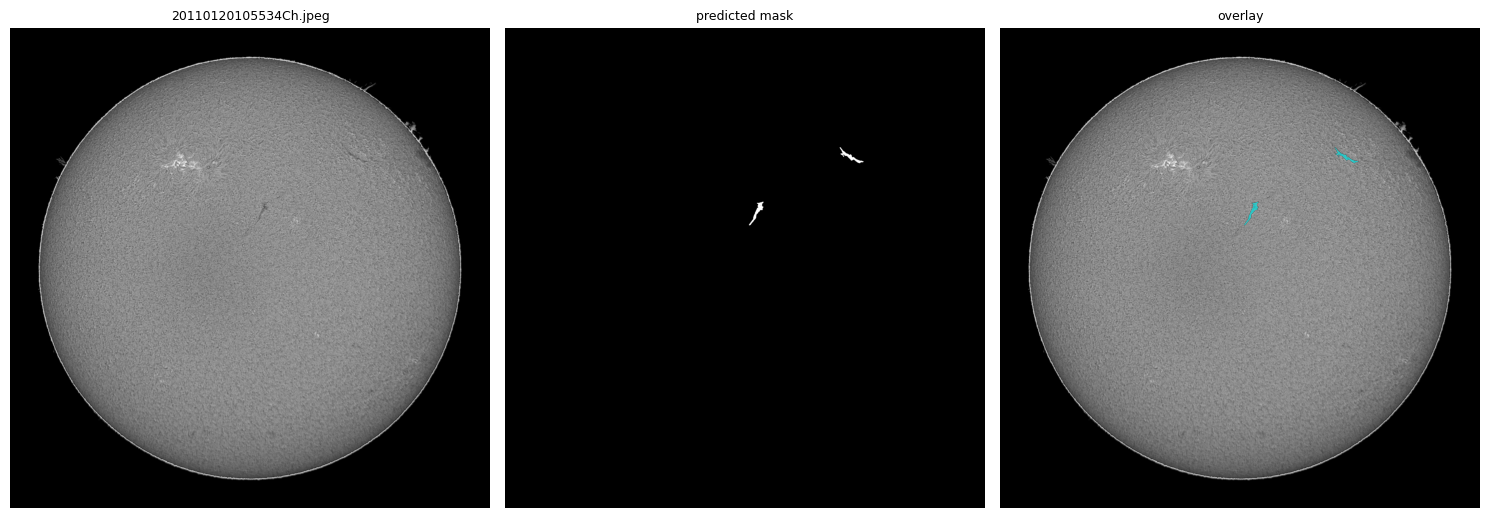

In [16]:
import matplotlib.pyplot as plt

with Image.open(test_paths[0]) as handle:
    original = np.asarray(handle.convert("L"))
figure, axes = plt.subplots(1, 3, figsize=(15, 5.2))
axes[0].imshow(original, cmap="gray"); axes[0].set_title(test_paths[0].name, fontsize=9)
axes[1].imshow(demo, cmap="gray"); axes[1].set_title("predicted mask", fontsize=9)
axes[2].imshow(original, cmap="gray")
axes[2].imshow(np.ma.masked_where(demo == 0, demo), cmap="cool", alpha=0.6)
axes[2].set_title("overlay", fontsize=9)
for axis in axes:
    axis.axis("off")
figure.tight_layout()
plt.show()

## 3. The whole test set

In [17]:
runtime.reset_peak_memory()
started = time.perf_counter()
rows, per_image = [], []
for path in tqdm(test_paths, desc="test images"):
    filaments = split_into_filaments(predict_native_mask(path))
    per_image.append(len(filaments))
    for index, filament in enumerate(filaments, start=1):
        rows.append((f"{path.stem}_{index}", rle_counts(filament)))

with SUBMISSION_PATH.open("w", encoding="utf-8", newline="") as handle:
    handle.write("filament_id,segmentation_rle\n")
    for filament_id, encoded in rows:
        handle.write(f"{filament_id},{encoded}\n")

stats = {"path": str(SUBMISSION_PATH), "images": len(per_image), "filaments": len(rows),
         "filaments_per_image": float(np.mean(per_image)),
         "images_without_filaments": int(sum(1 for c in per_image if c == 0)),
         "seconds": time.perf_counter() - started,
         "gpu_memory_gb": runtime.reserved_memory_gb(), "recipe": recipe}
(EXPERIMENT_DIR / "metrics" / "submission_stats.json").write_text(
    json.dumps(stats, indent=2, default=float), encoding="utf-8")
print(json.dumps(stats, indent=2, default=float))

test images: 100%|██████████| 180/180 [03:40<00:00,  1.23s/it]

{
  "path": "/Users/fp/GitHub Repos/MachineLearning-Project/submission.csv",
  "images": 180,
  "filaments": 1438,
  "filaments_per_image": 7.988888888888889,
  "images_without_filaments": 3,
  "seconds": 220.65954979200615,
  "gpu_memory_gb": 2.5032196044921875,
  "recipe": {
    "experiment_id": "15",
    "checkpoint": "experiments/15/checkpoints/best_model.pt",
    "checkpoint_epoch": 12,
    "selection_objective": "pq",
    "image_size": 1536,
    "tile": null,
    "threshold": 0.8,
    "close": 0,
    "min_size": 320,
    "gate": 0.95,
    "tta": true,
    "validation_dice": 0.6768689690394102,
    "validation_pq": 0.4197971965005265
  }
}


## 4. Sanity checks before uploading

A malformed submission scores zero, and the feedback loop on Kaggle is slow. These
checks cost a second and catch the mistakes that actually happen: a missing header,
duplicate ids, an RLE that does not decode, a mask at the wrong resolution.

In [18]:
lines = SUBMISSION_PATH.read_text().splitlines()
header, body = lines[0], lines[1:]
assert header == "filament_id,segmentation_rle", f"unexpected header: {header}"
ids = [line.split(",", 1)[0] for line in body]
assert len(ids) == len(set(ids)), "duplicate filament ids"
stems = {i.rsplit("_", 1)[0] for i in ids}
assert stems <= {p.stem for p in test_paths}, "ids that match no test image"

areas = []
for line in body[::40]:
    decoded = mask_util.decode({"size": [NATIVE, NATIVE],
                                "counts": line.split(",", 1)[1].encode("ascii")})
    assert decoded.shape == (NATIVE, NATIVE)
    areas.append(int(decoded.sum()))
assert min(areas) > 0, "an RLE decodes to an empty mask"

print(f"rows                    : {len(body)}")
print(f"images represented      : {len(stems)} / {len(test_paths)}")
print(f"filaments per image     : {stats['filaments_per_image']:.1f}")
print(f"decoded areas (sampled) : min {min(areas)}, median {int(np.median(areas))}, max {max(areas)}")
print(f"\nOK -> upload {SUBMISSION_PATH.name} "
      f"(validation Dice {recipe['validation_dice']:.3f} / PQ {recipe['validation_pq']:.3f})")

rows                    : 1438
images represented      : 177 / 180
filaments per image     : 8.0
decoded areas (sampled) : min 412, median 1405, max 8493

OK -> upload submission.csv (validation Dice 0.677 / PQ 0.420)
